# Analysing Campus Deplatforming Incidents from 1998

In [1]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
pwd

'/Users/anushasubramanian/Desktop/deplatforming'

In [3]:
df = pd.read_csv("data/campus_deplatforming_analysis.csv")
df.head()

,year,school,state,school_type,subject,type_of_expression,controversy_topics,outcome,url,sources,political_motives_source,petition_for,petition_against,remediation,explanation,public_response,coverage
0,2025,University of Washington,Washington,Public,Olivia Krolczyk,Campus Speech,Gender,Substantial Event Disruption,#campus-deplatforming/campus-deplatforming-det...,"Student Group(s), Student(s)",From the Left,No,No,No,Krolczyk was invited to speak on campus about ...,Disingenuous. In a statement a university spo...,['https://www.dailyuw.com/news/uw-turning-poin...
1,2025,"Rutgers University, New Brunswick",New Jersey,Public,Joshua Johnson,Campus Speech,Race,Revoked,#campus-deplatforming/campus-deplatforming-det...,"Administrator(s), Politician(s)",From the Right,No,No,No,Johnson was scheduled to speak at a virtual mi...,Neutral. An email sent to registered attendee...,['https://www.insidehighered.com/news/quick-ta...
2,2025,"Rutgers University, New Brunswick",New Jersey,Public,Gary Courtney,Campus Speech,Race,Revoked,#campus-deplatforming/campus-deplatforming-det...,"Administrator(s), Politician(s)",From the Right,No,No,No,Courtney was scheduled to speak at a virtual m...,Neutral. An email sent to registered attendee...,['https://www.insidehighered.com/news/quick-ta...
3,2025,"Rutgers University, New Brunswick",New Jersey,Public,Tammi Ferguson,Campus Speech,Race,Revoked,#campus-deplatforming/campus-deplatforming-det...,"Administrator(s), Politician(s)",From the Right,No,No,No,Ferguson was scheduled to speak at a virtual m...,Neutral. An email sent to registered attendee...,['https://www.insidehighered.com/news/quick-ta...
4,2025,"Rutgers University, New Brunswick",New Jersey,Public,Dennis Johnson,Campus Speech,Race,Revoked,#campus-deplatforming/campus-deplatforming-det...,"Administrator(s), Politician(s)",From the Right,No,No,No,Johnson was scheduled to speak at a virtual mi...,Neutral. An email sent to registered attendee...,['https://www.insidehighered.com/news/quick-ta...


## Clean Up

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1702 entries, 0 to 1701
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   year                      1702 non-null   int64 
 1   school                    1702 non-null   object
 2   state                     1702 non-null   object
 3   school_type               1702 non-null   object
 4   subject                   1702 non-null   object
 5   type_of_expression        1702 non-null   object
 6   controversy_topics        1702 non-null   object
 7   outcome                   1702 non-null   object
 8   url                       1702 non-null   object
 9   sources                   1702 non-null   object
 10  political_motives_source  1694 non-null   object
 11  petition_for              1702 non-null   object
 12  petition_against          1702 non-null   object
 13  remediation               1700 non-null   object
 14  explanation             

## Simple EDA metrics

#### Campus deplatforming incidents per year

<Axes: xlabel='year'>

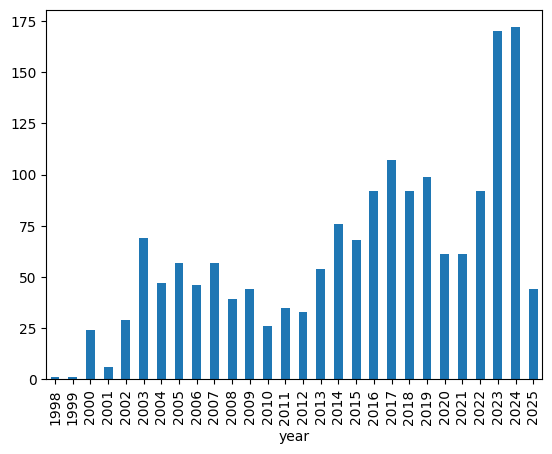

In [5]:
df["year"].value_counts().sort_index().plot(kind ="bar")

#### Campus deplatforming incidents per school

<Axes: ylabel='school'>

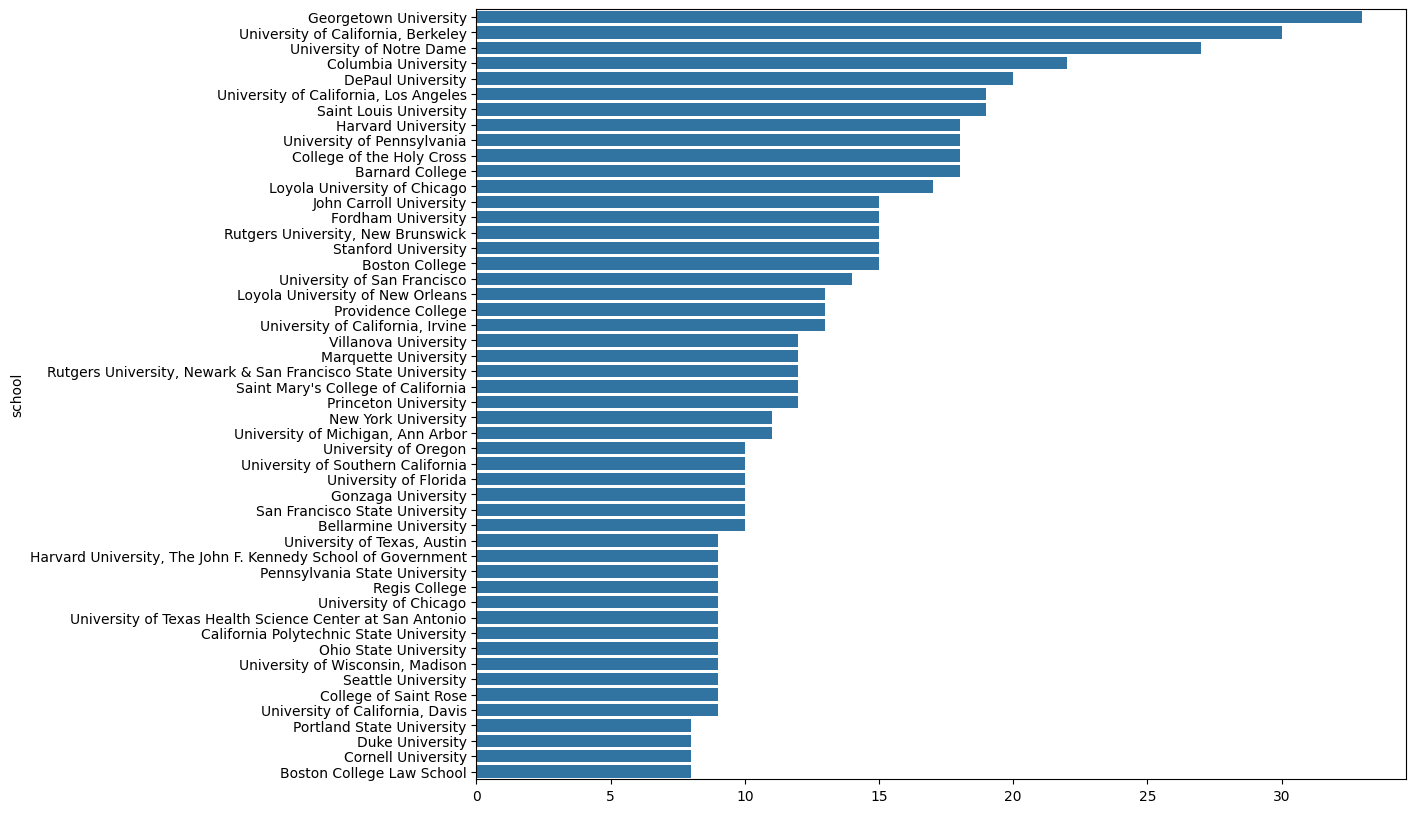

In [6]:
plt.figure(figsize=(12, 10))

sns.barplot(x=df["school"].value_counts()[:50].values,  
            y=df["school"].value_counts()[:50].index,
            orient='h')

#### Campus deplatforming incidents per public/private

In [7]:
df["school_type"].value_counts()

school_type
Religious                  633
Public                     616
Secular                    427
Community College           25
Federal Service Academy      1
Name: count, dtype: int64

#### Campus deplatforming incidents per type of expression

In [8]:
df["type_of_expression"].value_counts()

type_of_expression
Campus Speech          894
Commencement Speech    359
Performance            306
Artwork                107
Cinema                  32
Other                    4
Name: count, dtype: int64

## QUESTION: What is Not Applicable?

In [9]:
df["remediation"].value_counts()

remediation
Not Applicable    971
No                618
Yes               107
Unknown             2
no                  1
yes                 1
Name: count, dtype: int64

In [10]:
not_applicable = df[df["remediation"] == "Not Applicable"]

In [11]:
#why is it not applicable if there is a rejected or revoked etc.
not_applicable["outcome"].value_counts()

outcome
Disinvitation Attempt           538
Cancellation Attempt            217
Attempted Disruption            142
Substantial Event Disruption     43
Rejected                         17
Revoked                           9
Withdrew                          3
Postponed                         1
Canceled                          1
Name: count, dtype: int64

In [12]:
not_applicable[not_applicable["outcome"] == "Revoked"]["explanation"].iloc[0]
# ask about this example

'The Barnard Center for Research on Women was scheduled to host a panel titled "Resistance 101" and Eren was one of the panelists. At the start of the event, student organizers said they were being forced to hold the event at Columbia University\'s Q House, an LGTBQ+ community at Columbia, because of a student complaint to Barnard\'s administration. The panel discussion occurred successfully at the Q House and was livestreamed over Zoom.'

#### Campus deplatforming incidents per political motivation of who asked for censorship

In [13]:
df["political_motives_source"].value_counts()

political_motives_source
From the Left                       817
From the Right                      798
Not Applicable                       77
From the Left and From the Right      2
Name: count, dtype: int64

#### so the left protested more than the right. 

But which ones were accepted more?

In [14]:
df["outcome"].value_counts().index

Index(['Disinvitation Attempt', 'Revoked', 'Cancellation Attempt',
       'Substantial Event Disruption', 'Attempted Disruption', 'Rejected',
       'Withdrew', 'Canceled', 'Removed', 'Postponed'],
      dtype='object', name='outcome')

In [15]:
df.pivot_table(index = "political_motives_source",
              columns = "outcome",
              values = "type_of_expression",
              aggfunc="count")

outcome,Attempted Disruption,Canceled,Cancellation Attempt,Disinvitation Attempt,Postponed,Rejected,Removed,Revoked,Substantial Event Disruption,Withdrew
political_motives_source,,,,,,,,,,
From the Left,138.0,27.0,19.0,238.0,6.0,15.0,12.0,151.0,176.0,35.0
From the Left and From the Right,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN
From the Right,11.0,29.0,198.0,295.0,22.0,50.0,20.0,125.0,29.0,19.0
Not Applicable,7.0,NaN,2.0,18.0,1.0,NaN,9.0,29.0,6.0,5.0


In [16]:
len(df[(df["political_motives_source"] == "From the Left") & (df["outcome"] == "Attempted Disruption")])

138

In [17]:
#encoding success as 0 or 1

df["successful_censorship"] = ""

In [18]:
unsuccessful_outcomes = ["Disinvitation Attempt", "Cancellation Attempt", "Attempted Disruption"]

In [19]:
df.loc[df["outcome"].isin(unsuccessful_outcomes), "successful_censorship"] = 0
df.loc[~df["outcome"].isin(unsuccessful_outcomes), "successful_censorship"] = 1

In [20]:
df[["outcome","successful_censorship"]].head(10)

,outcome,successful_censorship
0,Substantial Event Disruption,1
1,Revoked,1
2,Revoked,1
3,Revoked,1
4,Revoked,1
5,Revoked,1
6,Revoked,1
7,Revoked,1
8,Revoked,1
9,Disinvitation Attempt,0


In [21]:
df.pivot_table(index = "political_motives_source",
              columns = "successful_censorship",
              values = "type_of_expression",
              aggfunc="count")

successful_censorship,0,1
political_motives_source,,
From the Left,395.0,422.0
From the Left and From the Right,2.0,NaN
From the Right,504.0,294.0
Not Applicable,27.0,50.0


left protested 817 times, succeeded 422 times and lost 395 times

right protested 798 times, succeeded 294 times and failed 504 times

In [22]:
422/817 # 51% of the time, the university let the left censor the right

0.5165238678090576

In [23]:
294/798 # 36% of the time, the universe let the right censor the left

0.3684210526315789

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1702 entries, 0 to 1701
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   year                      1702 non-null   int64 
 1   school                    1702 non-null   object
 2   state                     1702 non-null   object
 3   school_type               1702 non-null   object
 4   subject                   1702 non-null   object
 5   type_of_expression        1702 non-null   object
 6   controversy_topics        1702 non-null   object
 7   outcome                   1702 non-null   object
 8   url                       1702 non-null   object
 9   sources                   1702 non-null   object
 10  political_motives_source  1694 non-null   object
 11  petition_for              1702 non-null   object
 12  petition_against          1702 non-null   object
 13  remediation               1700 non-null   object
 14  explanation             

### Calculate difference between success rate of left and right censorship

proxy for who the state is censoring more or giving into more

In [25]:
# subset the main dataframe and only take incidents 
# that were directly the attempt of the left or right wing to censor the other
# ignore "not applicable" and left and right wing both

censorship_success = df[["school","state","political_motives_source","outcome","successful_censorship","remediation"]]
censorship_success = censorship_success[censorship_success["political_motives_source"].isin(["From the Right", "From the Left"])]
censorship_success.head()

,school,state,political_motives_source,outcome,successful_censorship,remediation
0,University of Washington,Washington,From the Left,Substantial Event Disruption,1,No
1,"Rutgers University, New Brunswick",New Jersey,From the Right,Revoked,1,No
2,"Rutgers University, New Brunswick",New Jersey,From the Right,Revoked,1,No
3,"Rutgers University, New Brunswick",New Jersey,From the Right,Revoked,1,No
4,"Rutgers University, New Brunswick",New Jersey,From the Right,Revoked,1,No


In [26]:
censorship_success.shape

(1615, 6)

In [27]:
censorship_success[censorship_success["state"] == "North Dakota"]

,school,state,political_motives_source,outcome,successful_censorship,remediation
412,North Dakota State University,North Dakota,From the Left,Attempted Disruption,0,No


In [28]:
censorship_success.groupby('state').size()

state
Alabama                   7
Arizona                  13
Arkansas                  7
California              230
Colorado                 10
Connecticut              28
Delaware                  3
District of Columbia     60
Florida                  40
Georgia                  19
Hawaii                    1
Idaho                     7
Illinois                 78
Indiana                  61
Iowa                      9
Kansas                    8
Kentucky                 18
Louisiana                22
Maine                     3
Maryland                 34
Massachusetts           139
Michigan                 44
Minnesota                23
Mississippi               2
Missouri                 25
Montana                   5
Nebraska                  7
Nevada                    1
New Hampshire            11
New Jersey               52
New Mexico               11
New York                182
North Carolina           32
North Dakota              1
Ohio                     52
Oklahoma      

In [29]:
# total attempts to censor from each political side per state
total_attempts = censorship_success.pivot_table(
    index="state", 
    columns="political_motives_source", 
    values="successful_censorship",  # Using this column just for counting
    aggfunc="count"
)
total_attempts.head()

political_motives_source,From the Left,From the Right
state,,
Alabama,3.0,4.0
Arizona,8.0,5.0
Arkansas,3.0,4.0
California,137.0,93.0
Colorado,8.0,2.0


In [30]:
# number of successful censorship attempts from each political side per state

censorship_counts = censorship_success.pivot_table(index = "state",
                              columns = "political_motives_source",
                              values = "successful_censorship",
                              aggfunc="sum")
censorship_counts.head()

political_motives_source,From the Left,From the Right
state,,
Alabama,0,1
Arizona,2,1
Arkansas,3,4
California,84,29
Colorado,4,0


In [31]:
censorship_success_pct = (censorship_counts / total_attempts * 100).round(2)
censorship_success_pct.head()

political_motives_source,From the Left,From the Right
state,,
Alabama,0.0,25.0
Arizona,25.0,20.0
Arkansas,100.0,100.0
California,61.313869,31.182796
Colorado,50.0,0.0


In [32]:
censorship_success_pct.reset_index(inplace = True)

In [33]:
censorship_success_pct["From the Right"].fillna(0,inplace=True)
censorship_success_pct["From the Left"].fillna(0,inplace=True)

/var/folders/2_/nl4h85lj1jqcl64vgwgvqnh40000gn/T/ipykernel_84948/1860958871.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  censorship_success_pct["From the Right"].fillna(0,inplace=True)
/var/folders/2_/nl4h85lj1jqcl64vgwgvqnh40000gn/T/ipykernel_84948/1860958871.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', T

In [34]:
censorship_success_pct["censor_diff"] = censorship_success_pct["From the Left"] - censorship_success_pct["From the Right"]
censorship_success_pct.head()

political_motives_source,state,From the Left,From the Right,censor_diff
0,Alabama,0.000000,25.000000,-25.000000
1,Arizona,25.000000,20.000000,5.000000
2,Arkansas,100.000000,100.000000,0.000000
3,California,61.313869,31.182796,30.131073
4,Colorado,50.000000,0.000000,50.000000


In [35]:
censorship_success[censorship_success["state"] == "Idaho"]

,school,state,political_motives_source,outcome,successful_censorship,remediation
67,"Brigham Young University, Idaho",Idaho,From the Right,Revoked,1,No
238,Lewis-Clark State College,Idaho,From the Right,Removed,1,No
239,Lewis-Clark State College,Idaho,From the Right,Removed,1,No
240,Lewis-Clark State College,Idaho,From the Right,Removed,1,No
241,Lewis-Clark State College,Idaho,From the Right,Removed,1,No
242,Lewis-Clark State College,Idaho,From the Right,Removed,1,No
243,Lewis-Clark State College,Idaho,From the Right,Removed,1,No


In [36]:
censorship_success_pct[["state","censor_diff"]].to_clipboard()

In [37]:
censorship_success_pct.to_clipboard()

In [38]:
censorship_success[censorship_success["state"] == "Hawaii"]

,school,state,political_motives_source,outcome,successful_censorship,remediation
1515,"University of Hawaii, Manoa",Hawaii,From the Right,Disinvitation Attempt,0,Not Applicable


### What is the Trend in Campus deplatforming events 

In [39]:
df.groupby("year")["year"].count().to_clipboard()

In [40]:
pd.crosstab(df["year"],df["political_motives_source"]).to_clipboard()

## Topics of Controversy

In [41]:
df.head()

,year,school,state,school_type,subject,type_of_expression,controversy_topics,outcome,url,sources,political_motives_source,petition_for,petition_against,remediation,explanation,public_response,coverage,successful_censorship
0,2025,University of Washington,Washington,Public,Olivia Krolczyk,Campus Speech,Gender,Substantial Event Disruption,#campus-deplatforming/campus-deplatforming-det...,"Student Group(s), Student(s)",From the Left,No,No,No,Krolczyk was invited to speak on campus about ...,Disingenuous. In a statement a university spo...,['https://www.dailyuw.com/news/uw-turning-poin...,1
1,2025,"Rutgers University, New Brunswick",New Jersey,Public,Joshua Johnson,Campus Speech,Race,Revoked,#campus-deplatforming/campus-deplatforming-det...,"Administrator(s), Politician(s)",From the Right,No,No,No,Johnson was scheduled to speak at a virtual mi...,Neutral. An email sent to registered attendee...,['https://www.insidehighered.com/news/quick-ta...,1
2,2025,"Rutgers University, New Brunswick",New Jersey,Public,Gary Courtney,Campus Speech,Race,Revoked,#campus-deplatforming/campus-deplatforming-det...,"Administrator(s), Politician(s)",From the Right,No,No,No,Courtney was scheduled to speak at a virtual m...,Neutral. An email sent to registered attendee...,['https://www.insidehighered.com/news/quick-ta...,1
3,2025,"Rutgers University, New Brunswick",New Jersey,Public,Tammi Ferguson,Campus Speech,Race,Revoked,#campus-deplatforming/campus-deplatforming-det...,"Administrator(s), Politician(s)",From the Right,No,No,No,Ferguson was scheduled to speak at a virtual m...,Neutral. An email sent to registered attendee...,['https://www.insidehighered.com/news/quick-ta...,1
4,2025,"Rutgers University, New Brunswick",New Jersey,Public,Dennis Johnson,Campus Speech,Race,Revoked,#campus-deplatforming/campus-deplatforming-det...,"Administrator(s), Politician(s)",From the Right,No,No,No,Johnson was scheduled to speak at a virtual mi...,Neutral. An email sent to registered attendee...,['https://www.insidehighered.com/news/quick-ta...,1


In [42]:
df["type_of_expression"].value_counts()

type_of_expression
Campus Speech          894
Commencement Speech    359
Performance            306
Artwork                107
Cinema                  32
Other                    4
Name: count, dtype: int64

In [43]:
df.pivot_table(index = "type_of_expression",
              columns = "political_motives_source",
              values = "year",
              aggfunc="count")


political_motives_source,From the Left,From the Left and From the Right,From the Right,Not Applicable
type_of_expression,,,,
Artwork,45.0,NaN,47.0,14.0
Campus Speech,582.0,2.0,264.0,39.0
Cinema,16.0,NaN,16.0,NaN
Commencement Speech,127.0,NaN,214.0,18.0
Other,3.0,NaN,NaN,1.0
Performance,44.0,NaN,257.0,5.0


In [44]:
df[df["controversy_topics"].str.contains("Israel")].groupby("year").size()

year
2002      2
2003      1
2004      1
2005      1
2006      6
2007      3
2008      1
2009      7
2010      2
2011      2
2012      6
2013      5
2014      2
2015      5
2016     11
2017     11
2018      4
2019     11
2020     13
2021     20
2022     16
2023     60
2024    110
2025     25
dtype: int64

In [45]:
df[df["controversy_topics"].str.contains("Israel")].pivot_table(index = "year",
                                                      columns = "political_motives_source",
                                                      values = "type_of_expression",
                                                          aggfunc="count")


political_motives_source,From the Left,From the Right,Not Applicable
year,,,
2002,NaN,2.0,NaN
2003,1.0,NaN,NaN
2004,1.0,NaN,NaN
2005,NaN,1.0,NaN
2006,2.0,4.0,NaN
2007,2.0,1.0,NaN
2008,NaN,1.0,NaN
2009,6.0,1.0,NaN
2010,2.0,NaN,NaN


In [46]:
df[(df["controversy_topics"].str.contains("Israel")) & (df["political_motives_source"] == "From the Right")].head()

,year,school,state,school_type,subject,type_of_expression,controversy_topics,outcome,url,sources,political_motives_source,petition_for,petition_against,remediation,explanation,public_response,coverage,successful_censorship
9,2025,"University of California, Berkeley",California,Public,Paola Bacchetta,Campus Speech,"Gender, Israeli-Palestinian Conflict",Disinvitation Attempt,#campus-deplatforming/campus-deplatforming-det...,Faculty,From the Right,No,No,Not Applicable,Bacchetta is scheduled to moderate at an upcom...,Honors. In a statement the university's assis...,['https://events.berkeley.edu/gws/event/283401...,0
10,2025,"University of California, Berkeley",California,Public,Walaa Al Qaisiya,Campus Speech,"Gender, Israeli-Palestinian Conflict",Disinvitation Attempt,#campus-deplatforming/campus-deplatforming-det...,Faculty,From the Right,No,No,Not Applicable,Al Qaisiya is scheduled to speak at an upcomin...,Honors. In a statement the university's assis...,['https://events.berkeley.edu/gws/event/283401...,0
11,2025,"University of California, Berkeley",California,Public,Nadine Naber,Campus Speech,"Gender, Israeli-Palestinian Conflict",Disinvitation Attempt,#campus-deplatforming/campus-deplatforming-det...,Faculty,From the Right,No,No,Not Applicable,Naber is scheduled to speak at an upcoming eve...,Honors. In a statement the university's assis...,['https://events.berkeley.edu/gws/event/283401...,0
12,2025,"University of California, Berkeley",California,Public,Nada Elia,Campus Speech,"Gender, Israeli-Palestinian Conflict",Disinvitation Attempt,#campus-deplatforming/campus-deplatforming-det...,Faculty,From the Right,No,No,Not Applicable,Elia is scheduled to speak at an upcoming even...,Honors. In a statement the university's assis...,['https://events.berkeley.edu/gws/event/283401...,0
17,2025,Georgetown University,District of Columbia,Religious,Ribhi Karajah,Campus Speech,Israeli-Palestinian Conflict,Postponed,#campus-deplatforming/campus-deplatforming-det...,"Activist(s), Student Group(s), Student(s)",From the Right,No,No,No,"Karajah, a member of the Popular Front for the...",None.,['https://www.thecollegefix.com/georgetown-law...,1


In [47]:
df[(df["controversy_topics"].str.contains("Israel")) & (df["political_motives_source"] == "From the Right")]["outcome"].value_counts()

outcome
Disinvitation Attempt           58
Revoked                         52
Postponed                       19
Substantial Event Disruption     9
Withdrew                         8
Cancellation Attempt             5
Canceled                         4
Removed                          2
Attempted Disruption             2
Rejected                         1
Name: count, dtype: int64

In [48]:
df[(df["controversy_topics"].str.contains("Israel")) & (df["political_motives_source"] == "From the Left")]["outcome"].value_counts()

outcome
Substantial Event Disruption    56
Attempted Disruption            45
Disinvitation Attempt           30
Revoked                         18
Canceled                         2
Postponed                        1
Withdrew                         1
Rejected                         1
Name: count, dtype: int64

In [49]:
conflict_df = df[df["controversy_topics"].str.contains("Israel")]

In [50]:
conflict_df.pivot_table(index = "political_motives_source",
              columns = "successful_censorship",
              values = "type_of_expression",
              aggfunc="count")

successful_censorship,0,1
political_motives_source,,
From the Left,75.0,79.0
From the Right,65.0,95.0
Not Applicable,NaN,7.0


In [51]:
# 51% of the times liberals censored the right 
79/(79+75)

0.512987012987013

In [52]:
# 59% of the times conservatives were able to censor liberals 
95/(95+65)

0.59375

In [53]:
conflict_df.pivot_table(index = "political_motives_source",
              columns = "remediation",
              values = "type_of_expression",
              aggfunc="count")

remediation,No,Not Applicable,Yes
political_motives_source,,,
From the Left,68.0,78.0,7.0
From the Right,74.0,57.0,29.0
Not Applicable,7.0,NaN,NaN


In [54]:
#left wanted right-wing to be censored, then 
7/(68+78+7) *100

4.57516339869281

In [55]:
29/(74+57+29) * 100

18.125

### While both were largely equal in successful censorship attempts, when the right wing was censored through left wing protests, the university eventually reversed the censorship and reinvited/relocated etc in 18% of the times vs just 4% in the reverse

In [56]:
df["controversy_topics"].value_counts().head(5)

controversy_topics
Gender, Religion, Sexuality     230
Israeli-Palestinian Conflict    221
Abortion                        122
Gender                           81
Race                             81
Name: count, dtype: int64

In [57]:
columbia = df[df["school"] == "Columbia University"]
columbia.head()

,year,school,state,school_type,subject,type_of_expression,controversy_topics,outcome,url,sources,political_motives_source,petition_for,petition_against,remediation,explanation,public_response,coverage,successful_censorship
61,2024,Columbia University,New York,Secular,Hillary Clinton,Campus Speech,"Gender, Israeli-Palestinian Conflict",Attempted Disruption,#campus-deplatforming/campus-deplatforming-det...,"Anonymous, Faculty",From the Left,No,No,Not Applicable,The university's School of International and P...,"Neutral: A university spokesperson said: ""Toda...",['https://www.algemeiner.com/2024/02/12/you-wi...,0
62,2024,Columbia University,New York,Secular,Linda Thomas-Greenfield,Campus Speech,"Gender, Israeli-Palestinian Conflict",Attempted Disruption,#campus-deplatforming/campus-deplatforming-det...,"Anonymous, Faculty",From the Left,No,No,Not Applicable,The university's School of International and P...,"Neutral: A university spokesperson said: ""Toda...",['https://www.algemeiner.com/2024/02/12/you-wi...,0
97,2024,Columbia University,New York,Secular,Mosab Hassan Yousef,Campus Speech,Israeli-Palestinian Conflict,Disinvitation Attempt,#campus-deplatforming/campus-deplatforming-det...,"Activist(s), Student Group(s), Student(s)",From the Left,No,No,Not Applicable,The New York chapter of the Council on America...,None.,['https://twitter.com/ColumbiaSJP/status/17704...,0
175,2024,Columbia University,New York,Secular,Tô Lâm,Campus Speech,"Foreign Affairs, Political Views",Disinvitation Attempt,#campus-deplatforming/campus-deplatforming-det...,Politician(s),From the Right,No,No,Not Applicable,"Lâm, the president of Vietnam and the Communis...","Neutral. A university spokesperson said: ""Col...",['https://japan-forward.com/columbia-universit...,0
225,2023,Columbia University,New York,Secular,Hillary Clinton,Campus Speech,Foreign Affairs,Attempted Disruption,#campus-deplatforming/campus-deplatforming-det...,General Public,From the Left,No,No,Not Applicable,"An anti-war protester shouted at Clinton, one ...",NaN,['https://twitter.com/JosBtrigga/status/171655...,0


In [58]:
columbia.shape

(22, 18)

In [59]:
columbia["type_of_expression"].value_counts()

type_of_expression
Campus Speech          19
Cinema                  1
Performance             1
Commencement Speech     1
Name: count, dtype: int64

In [60]:
columbia["controversy_topics"].value_counts()

controversy_topics
Foreign Affairs                                                   8
Gender, Israeli-Palestinian Conflict                              2
Israeli-Palestinian Conflict, Race                                2
Immigration                                                       2
Israeli-Palestinian Conflict                                      1
Foreign Affairs, Political Views                                  1
Race, Sexuality                                                   1
Immigration, Race                                                 1
Civil Liberties, Foreign Affairs, Israeli-Palestinian Conflict    1
Israeli-Palestinian Conflict, Sexuality                           1
Foreign Affairs, Israeli-Palestinian Conflict                     1
Abortion,  Civil Liberties, Foreign Affairs, Sexuality            1
Name: count, dtype: int64

In [61]:
columbia["political_motives_source"].value_counts()

political_motives_source
From the Left     14
Not Applicable     5
From the Right     3
Name: count, dtype: int64

In [62]:
df[df["year"] == 2024]["controversy_topics"].value_counts()

controversy_topics
Israeli-Palestinian Conflict                                                                       89
Gender                                                                                             15
Political Views                                                                                     8
Israeli-Palestinian Conflict, Race                                                                  6
Gender, Political Views, Race                                                                       4
Other                                                                                               4
Gender, Sexuality                                                                                   4
Civil Liberties, Race                                                                               3
Foreign Affairs, Israeli-Palestinian Conflict                                                       3
Abortion, Religion                                             

In [63]:
df.pivot_table(index = "political_motives_source",
              columns = "remediation",
              values = "type_of_expression",
              aggfunc="count")

remediation,No,Not Applicable,Unknown,Yes,no,yes
political_motives_source,,,,,,
From the Left,347.0,409.0,2.0,55.0,1.0,1.0
From the Left and From the Right,NaN,2.0,NaN,NaN,NaN,NaN
From the Right,224.0,525.0,NaN,49.0,NaN,NaN
Not Applicable,46.0,28.0,NaN,3.0,NaN,NaN


#### Really equal remediation except when israel gaza is concerned

In [64]:
55/(55+347+409+2+1+1)

0.06748466257668712

In [65]:
49/(49+224+525)

0.06140350877192982

In [66]:
yes_df = df[df["remediation"].isin(["Yes","yes"])]

In [67]:
yes_df.pivot_table(index = "year",
                  columns = "political_motives_source",
                  values = "remediation",
                  aggfunc="count").fillna(0).to_clipboard()

In [68]:
conflict_df[conflict_df["remediation"].isin(["Yes","yes"])]

,year,school,state,school_type,subject,type_of_expression,controversy_topics,outcome,url,sources,political_motives_source,petition_for,petition_against,remediation,explanation,public_response,coverage,successful_censorship
8,2025,University of Maryland,Maryland,Public,Elon Glassberg,Campus Speech,Israeli-Palestinian Conflict,Revoked,#campus-deplatforming/campus-deplatforming-det...,"Activist(s), Administrator(s)",From the Left,No,No,Yes,"Glassberg, the chief medical officer of the Is...","Neutral. A university spokesperson said: ""The...",['https://jewishinsider.com/2025/01/umd-medica...,1
66,2024,"University of California, Berkeley",California,Secular,Ran Bar-Yoshafat,Campus Speech,Israeli-Palestinian Conflict,Substantial Event Disruption,#campus-deplatforming/campus-deplatforming-det...,"Student Group(s), Student(s)",From the Left,No,No,Yes,Students Supporting Israel at Berkeley and the...,"Neutral: The university's chancellor, vice cha...",['https://www.dailywire.com/news/watch-uc-berk...,1
195,2024,Barnard College,New York,Secular,Israelism,Cinema,"Israeli-Palestinian Conflict, Race",Postponed,#campus-deplatforming/campus-deplatforming-det...,Administrator(s),From the Right,No,No,Yes,"Students, a faculty member, and staff organize...",Disingenuous. A college spokesperson said tha...,['https://jewishcurrents.org/civil-rights-law-...,1
196,2024,Barnard College,New York,Secular,Simone Zimmerman,Campus Speech,"Israeli-Palestinian Conflict, Race",Postponed,#campus-deplatforming/campus-deplatforming-det...,Administrator(s),From the Right,No,No,Yes,Zimmerman was scheduled to appear on a panel (...,Disingenuous. A college spokesperson said that...,['https://jewishcurrents.org/civil-rights-law-...,1
197,2024,Barnard College,New York,Secular,Nadia Saah,Campus Speech,"Israeli-Palestinian Conflict, Race",Postponed,#campus-deplatforming/campus-deplatforming-det...,Administrator(s),From the Right,No,No,Yes,Saah was scheduled to appear on a panel (along...,Disingenuous. A college spokesperson said that...,['https://jewishcurrents.org/civil-rights-law-...,1
198,2024,Barnard College,New York,Secular,Helga Tawil-Souri,Campus Speech,"Israeli-Palestinian Conflict, Race",Postponed,#campus-deplatforming/campus-deplatforming-det...,Administrator(s),From the Right,No,No,Yes,Tawil-Souri was scheduled to appear on a panel...,Disingenuous. A college spokesperson said that...,['https://jewishcurrents.org/civil-rights-law-...,1
199,2024,Barnard College,New York,Secular,Rachel Kahn-Troster,Campus Speech,"Israeli-Palestinian Conflict, Race",Postponed,#campus-deplatforming/campus-deplatforming-det...,Administrator(s),From the Right,No,No,Yes,Kahn-Troster was scheduled to appear on a pane...,Disingenuous. A college spokesperson said that...,['https://jewishcurrents.org/civil-rights-law-...,1
200,2024,Barnard College,New York,Secular,Yannik Thiem,Campus Speech,"Israeli-Palestinian Conflict, Race",Postponed,#campus-deplatforming/campus-deplatforming-det...,Administrator(s),From the Right,No,No,Yes,Thiem was scheduled to moderate a panel (featu...,Disingenuous. A college spokesperson said that...,['https://jewishcurrents.org/civil-rights-law-...,1
223,2023,"City University of New York, Hunter College",New York,Public,Israelism,Cinema,Israeli-Palestinian Conflict,Canceled,#campus-deplatforming/campus-deplatforming-det...,Administrator(s),From the Right,No,No,Yes,The college canceled a screening of the docume...,"Condemned Content of Expression, Appeased Prot...",['https://www.nytimes.com/2023/11/16/arts/isra...,1
271,2023,San Antonio College,Texas,Community College,Moureen Kaki,Campus Speech,Israeli-Palestinian Conflict,Postponed,#campus-deplatforming/campus-deplatforming-det...,Administrator(s),From the Right,No,No,Yes,History department students and faculty organi...,Neutral (Disingenuous). In an email to the cam...,['https://www.tpr.org/education/2023-12-12/stu...,1


In [69]:
conflict_df[conflict_df["remediation"].isin(["Yes","yes"])].pivot_table(index = "year",
                  columns = "political_motives_source",
                  values = "remediation",
                  aggfunc="count").fillna(0).to_clipboard()

In [70]:
top = list(df["school"].value_counts().head(10).index)

In [71]:
top_schools = df[df["school"].isin(top)]

In [72]:
top_schools.pivot_table(index = "school",
              columns = "year",
              values = "outcome",
              aggfunc="count").fillna(0).to_clipboard()

In [73]:
# disinvitation attempt 


df[df["type_of_expression"].isin(["Campus Speech","Commencement Speech"])]["school"].value_counts().head(10)

school
University of California, Berkeley                             30
Columbia University                                            20
Georgetown University                                          20
University of California, Los Angeles                          19
Harvard University                                             18
Barnard College                                                17
University of Pennsylvania                                     16
Rutgers University, New Brunswick                              15
Stanford University                                            14
Rutgers University, Newark & San Francisco State University    12
Name: count, dtype: int64

In [74]:
df[df["outcome"] == "Disinvitation Attempt"]["political_motives_source"].value_counts()

political_motives_source
From the Right                      295
From the Left                       238
Not Applicable                       18
From the Left and From the Right      2
Name: count, dtype: int64

In [75]:
postponed = df[df["outcome"] == "Postponed"]

In [76]:
postponed.pivot_table(index = "political_motives_source",
                     columns = "remediation",
                     values = "school",
                     aggfunc="count")

remediation,No,Not Applicable,Yes
political_motives_source,,,
From the Left,4.0,NaN,2.0
From the Right,4.0,1.0,17.0
Not Applicable,1.0,NaN,NaN


## Lets split topics and analyse

In [91]:
# splitting the list of topics into one row each
df_topic_split = df.copy()
df_topic_split['topics_list'] = df_topic_split['controversy_topics'].str.split(",\s*")

df_exploded_topics = df_topic_split.explode('topics_list')

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/var/folders/2_/nl4h85lj1jqcl64vgwgvqnh40000gn/T/ipykernel_84948/1928555032.py:3: SyntaxWarning: invalid escape sequence '\s'
  df_topic_split['topics_list'] = df_topic_split['controversy_topics'].str.split(",\s*")


In [92]:
df_exploded_topics.head()

,year,school,state,school_type,subject,type_of_expression,controversy_topics,outcome,url,sources,political_motives_source,petition_for,petition_against,remediation,explanation,public_response,coverage,successful_censorship,topics_list
0,2025,University of Washington,Washington,Public,Olivia Krolczyk,Campus Speech,Gender,Substantial Event Disruption,#campus-deplatforming/campus-deplatforming-det...,"Student Group(s), Student(s)",From the Left,No,No,No,Krolczyk was invited to speak on campus about ...,Disingenuous. In a statement a university spo...,['https://www.dailyuw.com/news/uw-turning-poin...,1,Gender
1,2025,"Rutgers University, New Brunswick",New Jersey,Public,Joshua Johnson,Campus Speech,Race,Revoked,#campus-deplatforming/campus-deplatforming-det...,"Administrator(s), Politician(s)",From the Right,No,No,No,Johnson was scheduled to speak at a virtual mi...,Neutral. An email sent to registered attendee...,['https://www.insidehighered.com/news/quick-ta...,1,Race
2,2025,"Rutgers University, New Brunswick",New Jersey,Public,Gary Courtney,Campus Speech,Race,Revoked,#campus-deplatforming/campus-deplatforming-det...,"Administrator(s), Politician(s)",From the Right,No,No,No,Courtney was scheduled to speak at a virtual m...,Neutral. An email sent to registered attendee...,['https://www.insidehighered.com/news/quick-ta...,1,Race
3,2025,"Rutgers University, New Brunswick",New Jersey,Public,Tammi Ferguson,Campus Speech,Race,Revoked,#campus-deplatforming/campus-deplatforming-det...,"Administrator(s), Politician(s)",From the Right,No,No,No,Ferguson was scheduled to speak at a virtual m...,Neutral. An email sent to registered attendee...,['https://www.insidehighered.com/news/quick-ta...,1,Race
4,2025,"Rutgers University, New Brunswick",New Jersey,Public,Dennis Johnson,Campus Speech,Race,Revoked,#campus-deplatforming/campus-deplatforming-det...,"Administrator(s), Politician(s)",From the Right,No,No,No,Johnson was scheduled to speak at a virtual mi...,Neutral. An email sent to registered attendee...,['https://www.insidehighered.com/news/quick-ta...,1,Race


In [93]:
df_exploded_topics['topics_list'].value_counts()

topics_list
Gender                          501
Sexuality                       457
Religion                        410
Race                            370
Israeli-Palestinian Conflict    325
Political Views                 240
Abortion                        235
Civil Liberties                 153
Immigration                      96
Foreign Affairs                  93
Other                            76
Criminal or Other Misconduct     76
Terrorism                        68
Class or Policy Issues           60
Scientific Views                 40
Health                           36
Police                           28
Environment                      23
Judiciary System                 22
other                            21
Elections                        17
                                 12
race                             10
sexuality                         6
gender                            4
Foreign Policy                    3
Animal Rights                     3
immigration     

In [94]:
# do some cleaning to now standardise this

corrections = {
    'Race': 'race',
    'sexulality': 'sexuality',
    'scientific view': 'scientific views',
    'gender identity': 'gender',
    "scientific views." : 'scientific views',
    "geder" : "gender",
    "Sexuality" : "sexuality"
    
}

# Apply replacements (case-insensitive)
df_exploded_topics['topics_list'] = df_exploded_topics['topics_list'].str.strip().str.lower().replace(corrections)

In [109]:
top_topics = list(df_exploded_topics['topics_list'].value_counts().head(11).index)

In [115]:
df_exploded_topics['topics_list'].value_counts().head(11)

topics_list
gender                          506
sexuality                       466
religion                        412
race                            380
israeli-palestinian conflict    325
political views                 240
abortion                        237
civil liberties                 154
immigration                      99
other                            97
foreign affairs                  93
Name: count, dtype: int64

In [110]:
topics_by_source = df_exploded_topics[df_exploded_topics["topics_list"].isin(top_topics)]

In [113]:
topics_by_source.pivot_table(index = "topics_list",
                              columns = "political_motives_source",
                              values = "outcome",
                              aggfunc="count").fillna(0).to_clipboard()